<a href="https://colab.research.google.com/github/RachmadAprisandhy/PembelajaranMesin/blob/main/JS05/JS05_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.

1. load data

In [2]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
path = '/content/drive/MyDrive/Pembelajaran mesin/voice.csv'
data = pd.read_csv(path)

1.Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.

In [7]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


2. preprocessing

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.iloc[:, :-1]   # semua fitur kecuali label
y = data.iloc[:, -1]    # label male/female

# Split data 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Standardisasi
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

3. buat model kNN

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Model KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Training
knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)

# Akurasi
accuracy = accuracy_score(y_test, y_pred)

print(f'Akurasi KNN: {accuracy:.4f}')

Akurasi KNN: 0.9737


In [10]:
print(y.unique())
print(y.value_counts())

['male' 'female']
label
male      1584
female    1584
Name: count, dtype: int64


2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector

# Model KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Seleksi fitur
sfs = SequentialFeatureSelector(
    knn,
    n_features_to_select=10,
    direction='forward',
    scoring='accuracy',
    cv=5
)

sfs.fit(X_train, y_train)

# Ambil nama fitur yang terpilih
selected_features = X.columns[sfs.get_support()]

print("Fitur yang terpilih:")
print(selected_features.tolist())

Fitur yang terpilih:
['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'skew', 'sp.ent', 'sfm', 'centroid', 'meanfun']


In [15]:
hasil_fitur = []

for jumlah in [5, 10, 15]:

    sfs = SequentialFeatureSelector(
        KNeighborsClassifier(n_neighbors=5),
        n_features_to_select=jumlah,
        direction='forward',
        scoring='accuracy',
        cv=5
    )

    sfs.fit(X_train, y_train)

    X_train_selected = sfs.transform(X_train)
    X_test_selected = sfs.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_selected, y_train)

    y_pred = knn.predict(X_test_selected)

    acc = accuracy_score(y_test, y_pred)

    hasil_fitur.append(acc)

    print(f"{jumlah} fitur = {acc:.4f}")

5 fitur = 0.9811
10 fitur = 0.9842
15 fitur = 0.9779


In [17]:
sfs = SequentialFeatureSelector(
    KNeighborsClassifier(n_neighbors=5),
    n_features_to_select=10,
    direction='forward',
    scoring='accuracy',
    cv=5
)

sfs.fit(X_train, y_train)

selected_features = X.columns[sfs.get_support()]

print("10 fitur terbaik:")
print(selected_features.tolist())

10 fitur terbaik:
['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'skew', 'sp.ent', 'sfm', 'centroid', 'meanfun']


3. Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai
k yang terbaik? Lampirkan grafika analisis dan alasan Anda.

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Ambil 10 fitur terbaik
X_train_selected = X_train[:, sfs.get_support()]
X_test_selected = X_test[:, sfs.get_support()]

train_acc = []
test_acc = []

# Uji nilai K dari 1 sampai 15
for k in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_selected, y_train)

    # Akurasi training
    y_pred_train = knn.predict(X_train_selected)
    train_acc.append(accuracy_score(y_train, y_pred_train))

    # Akurasi testing
    y_pred_test = knn.predict(X_test_selected)
    test_acc.append(accuracy_score(y_test, y_pred_test))

# Cari K terbaik berdasarkan akurasi testing
best_k = test_acc.index(max(test_acc)) + 1
best_accuracy = max(test_acc)

print(f'K terbaik: {best_k}')
print(f'Akurasi testing terbaik: {best_accuracy:.4f}')

K terbaik: 5
Akurasi testing terbaik: 0.9842


grafik

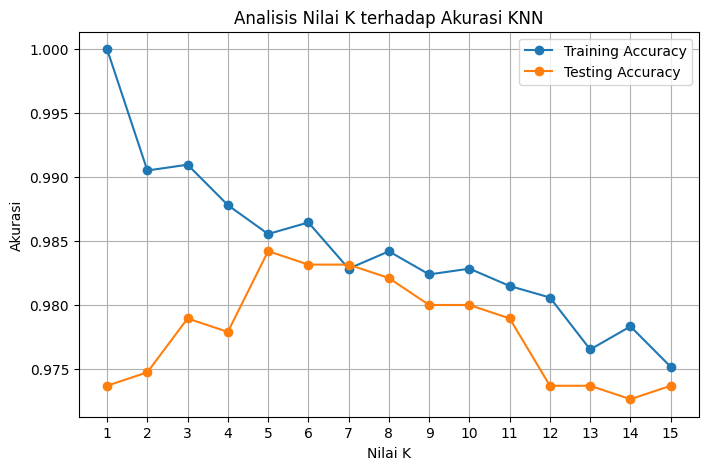

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 16),
    train_acc,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    range(1, 16),
    test_acc,
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.title('Analisis Nilai K terhadap Akurasi KNN')
plt.xticks(range(1, 16))
plt.legend()
plt.grid()
plt.show()

Berdasarkan hasil pengujian menggunakan 10 fitur terbaik, dilakukan percobaan nilai k dari 1 hingga 15. Berdasarkan grafik, nilai k = 5 menghasilkan akurasi testing tertinggi, yaitu sekitar 98,44%. Oleh karena itu, nilai k = 5 dipilih sebagai nilai k terbaik. Pada nilai k yang lebih besar, akurasi testing cenderung mengalami penurunan, sehingga penggunaan jumlah tetangga yang terlalu banyak kurang optimal untuk dataset ini. Nilai k = 5 dipilih karena memberikan kemampuan klasifikasi terbaik pada data testing.